# document extractor

In [2]:
# https://onlyoneaman.medium.com/i-tested-7-python-pdf-extractors-so-you-dont-have-to-2025-edition-c88013922257

import textract
text = textract.process(r"/Users/karthickthangadurai/PersonalPro/My_Projects/Otelio/data/hotel_rag_document_v2.pdf").decode()

In [3]:
print(text)

Grand Azure Bay Hotel - Detailed Information
Guide
Overview
Grand Azure Bay Hotel is a luxury beachfront property offering premium accommodation, fine
dining, and personalized guest experiences. The hotel is designed to cater to both business and
leisure travelers with a focus on comfort, safety, and service excellence.

Location & Accessibility
The hotel is located in Elysian Coast City, approximately 5 km from the city center and 20 km from
the international airport. It is easily accessible via taxi, public transport, and hotel-arranged shuttle
services. Nearby attractions include beaches, cultural landmarks, shopping districts, and nightlife
hubs.

Frequently Asked Questions - General
Check-in time is 2:00 PM and check-out time is 11:00 AM. Early check-in and late check-out are
subject to availability. The hotel provides free Wi-Fi, complimentary breakfast for select bookings,
and 24/7 customer support.

Hygiene & Cleanliness Protocols
The hotel follows strict hygiene standards ali

# unstructured

In [12]:
# pip install "unstructured[all-docs]"
from unstructured.partition.auto import partition
from pathlib import Path

PROJECT_ROOT = Path(__file__).resolve().parent.parent if '__file__' in locals() else Path('.').resolve().parent

"""
__file__: A built-in Python variable that contains the file path of the current script (e.g., "/Users/karthick/projects/Otelio/src/config.py").

Path(__file__): Converts that path string into a robust pathlib.Path object, allowing you to use object-oriented path manipulations.

"""

print(f"PROJECT_ROOT: {PROJECT_ROOT}")

pdf_path = PROJECT_ROOT / "data" / "hotel_rag_document_v2.pdf"

blocks = partition(filename=pdf_path, strategy="fast")

for block in blocks:
    print(f"{block.category}: {block.text}")

PROJECT_ROOT: /Users/karthickthangadurai/PersonalPro/My_Projects/Otelio
Title: Grand Azure Bay Hotel - Detailed Information Guide
Title: Overview
NarrativeText: Grand Azure Bay Hotel is a luxury beachfront property offering premium accommodation, fine dining, and personalized guest experiences. The hotel is designed to cater to both business and leisure travelers with a focus on comfort, safety, and service excellence.
Title: Location & Accessibility
NarrativeText: The hotel is located in Elysian Coast City, approximately 5 km from the city center and 20 km from the international airport. It is easily accessible via taxi, public transport, and hotel-arranged shuttle services. Nearby attractions include beaches, cultural landmarks, shopping districts, and nightlife hubs.
Title: Frequently Asked Questions - General
NarrativeText: Check-in time is 2:00 PM and check-out time is 11:00 AM. Early check-in and late check-out are subject to availability. The hotel provides free Wi-Fi, complimen

In [13]:
"""Evaluated PyMuPDF, textract, and unstructured; chose unstructured because its element-type 
classification (Title/NarrativeText) enables deterministic section-based chunking, whereas the plain-text extractors 
collapse headings into body text and would require brittle heuristics."""


from unstructured.partition.pdf import partition_pdf


pdf_path = PROJECT_ROOT / "data" / "hotel_rag_document_v2.pdf"

blocks = partition_pdf(
    filename=pdf_path,
    strategy="fast"
)


In [14]:
for block in blocks:
    print(f"{block.category}: {block.text}")

Title: Grand Azure Bay Hotel - Detailed Information Guide
Title: Overview
NarrativeText: Grand Azure Bay Hotel is a luxury beachfront property offering premium accommodation, fine dining, and personalized guest experiences. The hotel is designed to cater to both business and leisure travelers with a focus on comfort, safety, and service excellence.
Title: Location & Accessibility
NarrativeText: The hotel is located in Elysian Coast City, approximately 5 km from the city center and 20 km from the international airport. It is easily accessible via taxi, public transport, and hotel-arranged shuttle services. Nearby attractions include beaches, cultural landmarks, shopping districts, and nightlife hubs.
Title: Frequently Asked Questions - General
NarrativeText: Check-in time is 2:00 PM and check-out time is 11:00 AM. Early check-in and late check-out are subject to availability. The hotel provides free Wi-Fi, complimentary breakfast for select bookings, and 24/7 customer support.
Title: Hy

In [22]:
import pymupdf
import sys, pathlib

doc = pymupdf.open("/Users/karthickthangadurai/PersonalPro/My_Projects/Otelio/data/hotel_rag_document_v2.pdf")
for page in doc:
    print(page.get_text())

Grand Azure Bay Hotel - Detailed Information
Guide
Overview
Grand Azure Bay Hotel is a luxury beachfront property offering premium accommodation, fine
dining, and personalized guest experiences. The hotel is designed to cater to both business and
leisure travelers with a focus on comfort, safety, and service excellence.
Location & Accessibility
The hotel is located in Elysian Coast City, approximately 5 km from the city center and 20 km from
the international airport. It is easily accessible via taxi, public transport, and hotel-arranged shuttle
services. Nearby attractions include beaches, cultural landmarks, shopping districts, and nightlife
hubs.
Frequently Asked Questions - General
Check-in time is 2:00 PM and check-out time is 11:00 AM. Early check-in and late check-out are
subject to availability. The hotel provides free Wi-Fi, complimentary breakfast for select bookings,
and 24/7 customer support.

Hygiene & Cleanliness Protocols
The hotel follows strict hygiene standards aligne

# Chunking

In [23]:
from unstructured.chunking.title import chunk_by_title

chunks = chunk_by_title(blocks, combine_text_under_n_chars=0, include_orig_elements = True)

for chunk in chunks:
    print(chunk)
    print("\n\n" + "-"*80)

Grand Azure Bay Hotel - Detailed Information Guide


--------------------------------------------------------------------------------
Overview

Grand Azure Bay Hotel is a luxury beachfront property offering premium accommodation, fine dining, and personalized guest experiences. The hotel is designed to cater to both business and leisure travelers with a focus on comfort, safety, and service excellence.


--------------------------------------------------------------------------------
Location & Accessibility

The hotel is located in Elysian Coast City, approximately 5 km from the city center and 20 km from the international airport. It is easily accessible via taxi, public transport, and hotel-arranged shuttle services. Nearby attractions include beaches, cultural landmarks, shopping districts, and nightlife hubs.


--------------------------------------------------------------------------------
Frequently Asked Questions - General

Check-in time is 2:00 PM and check-out time is 11:00 

In [24]:
"""
Chunks carry a hotel metadata field; single-property today, but the schema and retrieval filter 
extend to multi-property without re-ingestion redesign.
"""

print(chunks[2].text)

Location & Accessibility

The hotel is located in Elysian Coast City, approximately 5 km from the city center and 20 km from the international airport. It is easily accessible via taxi, public transport, and hotel-arranged shuttle services. Nearby attractions include beaches, cultural landmarks, shopping districts, and nightlife hubs.


In [25]:
print(chunks[2].metadata.to_dict())

{'file_directory': '/Users/karthickthangadurai/PersonalPro/My_Projects/Otelio/data', 'filename': 'hotel_rag_document_v2.pdf', 'filetype': 'application/pdf', 'languages': ['eng'], 'last_modified': '2026-07-18T20:06:46', 'page_number': 1, 'orig_elements': 'eJztUz1v2zAQ/SsHDZ0cWZYtm85WBB0KtGmAupMRCCfqbF1NiQJJuTaC/PceZQdNP5YunToJd+/d1+PT9ikhQy11oeQ6uYVkrXC11rOiwKpaqHlRa6oozyu9Wyi9W6tkAklLAWsMKPynRFvrau4wkB9jg2c7hLIh3jdBMmoxS5VaK6m7Qt+4Do0gxbpI81WxFKS33IVYv92uVJpNIC+ydP04gZdwubiE+Xydqj/EI10SiT/7QG285IFPZD73qCl5FmDHhsqaHelg3TkSpl88OT89oAsN60NosNtjPTjk6YMAtkPz4Oz047mUz1ep89NPgQzb6Xj8tWeHLcVujRWsdLgva6uHUdFjnvb17oUYzv1IxL43rDGw7aZX2MjkAfejgtuEun3yOGZ9KFtb845pfJs8y5c32epmpjZ5dpstbxfLWN1LZdkNbUVOWLN4bKBT1D75YC+D4A281Zq854oNh3Mse9lnw8GMEv1qhUqhWurFSjRe4loVywWSymiXZXVOSuf/ygpKpbMfVpjPF5ewmM3S4vf4Qv9vhWiFMeP+4ud+7Z1NQzBeAuzBRCNRDdzBO3P2jB3cWVkK7sRNE5BDnD1xKxxzhgIOLeycbSFIDy0M0LIEOcCuhjz7CeYIdKMGaADZ9daFFN6HOJbQszTEq3cNwZERAp54Av1QiXgQHHY+1kzG7uPGN+gku5d9fTMEsTfI8x5ZmqRwT+gqaRmkUMepXlbQZqgJKkLdkJ+AH

# create schema for ChromaDB

In [26]:
from unstructured.staging.base import elements_from_base64_gzipped_json

records = []

hotel_id = str(chunks[0]).split('-')[0].strip().lower().replace(" ", "-")
hotel_name = str(chunks[0]).split('-')[0].strip()

for element, counter in zip(chunks[1:], range(1, len(chunks[1:]) + 1)):

    
    metadata = element.metadata.to_dict()

    id = f"{hotel_id}-{counter}"
    page_number = metadata["page_number"]
    title = ''
    
    content = ''

    orig_elements = elements_from_base64_gzipped_json(metadata["orig_elements"])

    for orig_element in orig_elements:
        
        content += orig_element.text + " : "

        if orig_element.category == "Title":

            title = orig_element.text

    doc = {
        'metadata': {
            'id': id,
            'hotel_name': hotel_name,
            'page_number': page_number,
            'title': title
        },
        'content': content
    }

    records.append(doc)

print(records[0])

{'metadata': {'id': 'grand-azure-bay-hotel-1', 'hotel_name': 'Grand Azure Bay Hotel', 'page_number': 1, 'title': 'Overview'}, 'content': 'Overview : Grand Azure Bay Hotel is a luxury beachfront property offering premium accommodation, fine dining, and personalized guest experiences. The hotel is designed to cater to both business and leisure travelers with a focus on comfort, safety, and service excellence. : '}


In [27]:
from unstructured.staging.base import elements_from_base64_gzipped_json

records = []

# hotel name from the document title (first chunk), split on " - " 
doc_title = str(chunks[0]).strip()
hotel_name = doc_title.split(" - ")[0].strip()          # "Grand Azure Bay Hotel"
hotel_slug = hotel_name.lower().replace(" ", "-")       # "grand-azure-bay-hotel"

for counter, element in enumerate(chunks[1:], start=1):
    metadata = element.metadata.to_dict()
    orig_elements = elements_from_base64_gzipped_json(metadata["orig_elements"])

    title = "General"
    parts = []
    for e in orig_elements:
        if e.category == "Title":
            title = e.text
        else:
            parts.append(e.text)
    narrative = " ".join(parts)

    if len(narrative) < 30:        # skip title-only / junk chunks
        continue

    records.append({
        "id": f"{hotel_slug}-{counter}",
        "content": f"{title}: {narrative}",
        "metadata": {
            "hotel_name": hotel_name,
            "section": title,
            "page_number": metadata.get("page_number", 1),
            "chunk_id": counter,
        },
    })

print(len(records))                 # expect 16
print(records[0]["content"][:100])  # expect "Overview: Grand Azure Bay Hotel is a luxury..."

15
Overview: Grand Azure Bay Hotel is a luxury beachfront property offering premium accommodation, fine


In [28]:
records

[{'id': 'grand-azure-bay-hotel-1',
  'content': 'Overview: Grand Azure Bay Hotel is a luxury beachfront property offering premium accommodation, fine dining, and personalized guest experiences. The hotel is designed to cater to both business and leisure travelers with a focus on comfort, safety, and service excellence.',
  'metadata': {'hotel_name': 'Grand Azure Bay Hotel',
   'section': 'Overview',
   'page_number': 1,
   'chunk_id': 1}},
 {'id': 'grand-azure-bay-hotel-2',
  'content': 'Location & Accessibility: The hotel is located in Elysian Coast City, approximately 5 km from the city center and 20 km from the international airport. It is easily accessible via taxi, public transport, and hotel-arranged shuttle services. Nearby attractions include beaches, cultural landmarks, shopping districts, and nightlife hubs.',
  'metadata': {'hotel_name': 'Grand Azure Bay Hotel',
   'section': 'Location & Accessibility',
   'page_number': 1,
   'chunk_id': 2}},
 {'id': 'grand-azure-bay-hotel-

# create embeddings and push to db

In [29]:
import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

client = chromadb.PersistentClient(path="../chroma_db")
ef = SentenceTransformerEmbeddingFunction(model_name="BAAI/bge-small-en-v1.5")
collection = client.get_or_create_collection(
    name="hotel_docs",
    embedding_function=ef,
    metadata={"hnsw:space": "cosine"},
)

collection.upsert(
    ids=[r["id"] for r in records],
    documents=[r["content"] for r in records],
    metadatas=[r["metadata"] for r in records],
)
print(f"Loaded {collection.count()} chunks")

# ---- the four-query retrieval test ----
for q in [
    "What is the famous dish in the hotel?",
    "How does the hotel ensure hygiene?",
    "Is vegetarian food available?",
    "What is the cancellation policy?",
]:
    res = collection.query(query_texts=[q], n_results=3)
    print(q, "->", [m["section"] for m in res["metadatas"][0]])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loaded 15 chunks
What is the famous dish in the hotel? -> ['Dining Experience', 'Famous Dishes', 'Common User Questions - Food']
How does the hotel ensure hygiene? -> ['Hygiene & Cleanliness Protocols', 'Common User Questions - Safety', 'Common User Questions - Food']
Is vegetarian food available? -> ['Common User Questions - Food', 'Famous Dishes', 'Common User Questions - Safety']
What is the cancellation policy? -> ['Cancellation & Modification Policy', 'Common User Questions - Booking', 'Reservation Process']


In [30]:
collection.query(query_texts="How does cricket work?", n_results=3)

{'ids': [['grand-azure-bay-hotel-15',
   'grand-azure-bay-hotel-12',
   'grand-azure-bay-hotel-10']],
 'embeddings': None,
 'documents': [['Common User Questions - Booking: Users often ask how to modify bookings, whether refunds are available, how to check reservation status, and what happens in case of no-show. The assistant is expected to handle such queries effectively.',
   'Reservation Process: Guests can make reservations through the hotel website, mobile app, or assistant. Required details include guest name, contact information, check-in/check-out dates, and room preferences. Confirmation is sent via email.',
   'Chef Expertise: The culinary team consists of internationally trained chefs who specialize in precision cooking techniques. Each dish follows standardized recipes to maintain consistency in taste and presentation.']],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'hotel_name': 'Grand Azure Bay Hotel',
    'section'

# cross - encoder reranking

In [ ]:
from sentence_transformers import CrossEncoder

rerank_model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

In [ ]:
"""Evaluated a cross-encoder re-ranker (mxbai-rerank-xsmall); scores confirmed sharper discrimination, 
but at 15 chunks top-3 recall was already 100%, so it's excluded from the pipeline to keep latency and dependencies minimal."""

from sentence_transformers import CrossEncoder

# Load the model, here we use our base sized model
model = CrossEncoder("mixedbread-ai/mxbai-rerank-xsmall-v1")

# Example query and documents
query = "How does the hotel ensure hygiene?"
documents = ['Hygiene & Cleanliness Protocols: The hotel follows strict hygiene standards aligned with international hospitality guidelines. Rooms are deep-cleaned after every checkout using hospital-grade disinfectants. High-touch areas such as door handles, elevators, and reception counters are sanitized multiple times a day.',
   'Common User Questions - Safety: Guests often ask whether the hotel follows COVID or health safety guidelines, whether food is hygienic, and how frequently rooms are cleaned. The hotel ensures full transparency and compliance with safety protocols.',
   'Common User Questions - Food: Guests frequently ask about vegetarian options, allergen information, spice levels, and availability of customized meals. The hotel accommodates dietary restrictions and provides detailed menu information.']
# Lets get the scores
results = model.rank(query, documents, return_documents=True, top_k=3)

results

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

# database connection

In [31]:
"""SQLite connection + schema for reservations."""

import sqlite3

import sys
from pathlib import Path

# Find the project root (one level up from 'experiments') and add it to sys.path
PROJECT_ROOT = str(Path('.').resolve().parent)
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)


from src.config import DB_PATH

SCHEMA = """
CREATE TABLE IF NOT EXISTS reservations (
    reservation_id  TEXT PRIMARY KEY,
    hotel_id        TEXT NOT NULL,
    guest_name      TEXT NOT NULL,
    email           TEXT NOT NULL,
    check_in        TEXT NOT NULL,   -- ISO YYYY-MM-DD (SQLite has no native date type)
    check_out       TEXT NOT NULL,
    room_type       TEXT NOT NULL DEFAULT 'standard',
    status          TEXT NOT NULL DEFAULT 'active'
                    CHECK (status IN ('active', 'cancelled')),
    created_at      TEXT NOT NULL,
    CHECK (check_out > check_in)
);
CREATE INDEX IF NOT EXISTS idx_res_email ON reservations(email);
"""

def get_connection():
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row  # rows behave like dicts: row["email"]
    conn.executescript(SCHEMA)
    return conn

# Reservation Tool

In [32]:
import re
import secrets
from datetime import datetime, date

In [33]:
def valid_date(value):
    try:
        return datetime.strptime(value, "%Y-%m-%d").date()
    except (ValueError, TypeError):
        return None

In [34]:
def create_reservation(guest_name, email, check_in, check_out,
                       room_type="standard"):
    
    """Create a reservation.

    Only call once the guest has given all four: name, email, check-in,
    check-out. Ask for anything missing. Never invent values.

    Args:
        guest_name: Guest's full name.
        email: Guest's email address.
        check_in: Arrival date, YYYY-MM-DD.
        check_out: Departure date, YYYY-MM-DD, after check_in.
        room_type: "standard", "deluxe", or "suite".

    Returns:
        Reservation ID and details, or an error message.
    """
    
    if not guest_name or not guest_name.strip():
        return {"ok": False, "error": "Guest name is required."}
    if not re.match(r"^[^@\s]+@[^@\s]+\.[^@\s]+$", email or ""):
        return {"ok": False, "error": "A valid email address is required."}

    ci, co = valid_date(check_in), valid_date(check_out)
    if not ci or not co:
        return {"ok": False, "error": "Dates must be in YYYY-MM-DD format."}
    if ci < date.today():
        return {"ok": False, "error": "Check-in date cannot be in the past."}
    if co <= ci:
        return {"ok": False, "error": "Check-out must be after check-in."}
    if room_type not in {"standard", "deluxe", "suite"}:
        return {"ok": False, "error": f"Room type must be one of: {', '.join(sorted({"standard", "deluxe", "suite"}))}."}

    rid = f"RES-{secrets.token_hex(3).upper()}"
    conn = get_connection()
    try:
        conn.execute(
            "INSERT INTO reservations VALUES (?,?,?,?,?,?,?,?,?)",
            (rid, "grand-azure-bay-hotel", guest_name.strip(), email.strip().lower(),
             check_in, check_out, room_type, "active",
             datetime.now().isoformat(timespec="seconds")),
        )
        conn.commit()
    finally:
        conn.close()

    return {"ok": True, "reservation_id": rid, "check_in": check_in,
            "check_out": check_out, "room_type": room_type}

In [35]:
NOT_FOUND = {"ok": False, "error": "No reservation found with that ID and email."}

def get_reservation(reservation_id, email):

    """Look up one reservation.

    Requires both the reservation ID and the email it was booked under; ask for
    whichever is missing. Returns a single reservation only — bulk listing is
    not possible.

    Args:
        reservation_id: Booking reference, e.g. "RES-A3F8C1".
        email: Email on the reservation.

    Returns:
        Reservation details, or a not-found message.
    """
    
    conn = get_connection()
    try:
        row = conn.execute(
            "SELECT * FROM reservations WHERE reservation_id = ? AND email = ?",
            (reservation_id.strip().upper(), email.strip().lower()),
        ).fetchone()
    finally:
        conn.close()

    if row is None:
        return NOT_FOUND
    return {"ok": True, "reservation_id": row["reservation_id"],
            "guest_name": row["guest_name"], "check_in": row["check_in"],
            "check_out": row["check_out"], "room_type": row["room_type"],
            "status": row["status"]}

In [36]:
def cancel_reservation(reservation_id, email):

    """Cancel a reservation.

    Requires both the reservation ID and the email it was booked under. Confirm
    with the guest before calling.

    Args:
        reservation_id: Booking reference, e.g. "RES-A3F8C1".
        email: Email on the reservation.

    Returns:
        Cancellation confirmation, or a not-found message.
    """
    
    conn = get_connection()
    try:
        row = conn.execute(
            "SELECT status FROM reservations WHERE reservation_id = ? AND email = ?",
            (reservation_id.strip().upper(), email.strip().lower()),
        ).fetchone()
        if row is None:
            return NOT_FOUND
        if row["status"] == "cancelled":
            return {"ok": True, "reservation_id": reservation_id,
                    "status": "cancelled", "note": "This reservation was already cancelled."}
        conn.execute(
            "UPDATE reservations SET status = 'cancelled' WHERE reservation_id = ?",
            (reservation_id.strip().upper(),),
        )
        conn.commit()
    finally:
        conn.close()

    return {"ok": True, "reservation_id": reservation_id, "status": "cancelled"}

In [37]:
r = create_reservation("Test Guest", "Test@Example.com", "2026-07-25", "2026-07-27")
print(r)
print(create_reservation("karthick", "bad-email", "2026-07-25", "2026-07-27"))
print(create_reservation("suriya", "suriya@b.com", "2020-01-01", "2020-01-05"))
print(get_reservation(r["reservation_id"], "test@example.com"))     # owner -> full record
print(get_reservation(r["reservation_id"], "hacker@evil.com"))      # wrong email -> NOT_FOUND
print(get_reservation("RES-000000", "test@example.com"))            # wrong id -> same message
print(cancel_reservation(r["reservation_id"], "test@example.com"))
print(cancel_reservation(r["reservation_id"], "test@example.com"))  # already cancelled

{'ok': True, 'reservation_id': 'RES-2C53FF', 'check_in': '2026-07-25', 'check_out': '2026-07-27', 'room_type': 'standard'}
{'ok': False, 'error': 'A valid email address is required.'}
{'ok': False, 'error': 'Check-in date cannot be in the past.'}
{'ok': True, 'reservation_id': 'RES-2C53FF', 'guest_name': 'Test Guest', 'check_in': '2026-07-25', 'check_out': '2026-07-27', 'room_type': 'standard', 'status': 'active'}
{'ok': False, 'error': 'No reservation found with that ID and email.'}
{'ok': False, 'error': 'No reservation found with that ID and email.'}
{'ok': True, 'reservation_id': 'RES-2C53FF', 'status': 'cancelled'}
{'ok': True, 'reservation_id': 'RES-2C53FF', 'status': 'cancelled', 'note': 'This reservation was already cancelled.'}


In [38]:
conn = get_connection()

query = 'SELECT * FROM reservations'

row = conn.execute(query).fetchall()

for r in row:
    print(r.keys())

['reservation_id', 'hotel_id', 'guest_name', 'email', 'check_in', 'check_out', 'room_type', 'status', 'created_at']
['reservation_id', 'hotel_id', 'guest_name', 'email', 'check_in', 'check_out', 'room_type', 'status', 'created_at']
['reservation_id', 'hotel_id', 'guest_name', 'email', 'check_in', 'check_out', 'room_type', 'status', 'created_at']
['reservation_id', 'hotel_id', 'guest_name', 'email', 'check_in', 'check_out', 'room_type', 'status', 'created_at']
['reservation_id', 'hotel_id', 'guest_name', 'email', 'check_in', 'check_out', 'room_type', 'status', 'created_at']
['reservation_id', 'hotel_id', 'guest_name', 'email', 'check_in', 'check_out', 'room_type', 'status', 'created_at']
['reservation_id', 'hotel_id', 'guest_name', 'email', 'check_in', 'check_out', 'room_type', 'status', 'created_at']
['reservation_id', 'hotel_id', 'guest_name', 'email', 'check_in', 'check_out', 'room_type', 'status', 'created_at']


# search hotelm info 

In [39]:
_client = chromadb.PersistentClient(path="../chroma_db")
_ef = SentenceTransformerEmbeddingFunction(model_name="BAAI/bge-small-en-v1.5")
_collection = _client.get_collection(name="hotel_docs", embedding_function=_ef)


TOP_K = 3                  # number of chunks to return for LLM context
DISTANCE_THRESHOLD = 0.7   # best distance above this => "no relevant info" sentinel
NO_RESULT_SENTINEL = "No relevant information found in the hotel document."
DEFAULT_HOTEL = "Grand Azure Bay Hotel"  # used for queries when no hotel name is found

def search_hotel_info(query, n_results=TOP_K):
    """Search the hotel's information document.

    Use for any factual question about the hotel — location, timings, amenities,
    hygiene, safety, dining, policies. Always search before answering; never
    answer from your own knowledge. If nothing relevant is found, say so.

    Args:
        query: The guest's question.

    Returns:
        Relevant document sections, or a not-found message.
    """
    res = _collection.query(
        query_texts=[query],
        n_results=n_results,
        where={"hotel_name": DEFAULT_HOTEL},
        include=["documents", "metadatas", "distances"],
    )

    print(res)
    docs, metas, dists = res["documents"][0], res["metadatas"][0], res["distances"][0]

    if not docs or dists[0] > DISTANCE_THRESHOLD:
        return NO_RESULT_SENTINEL

    return "\n\n".join(
        f"[Section: {m['section']}]\n{d}" for d, m in zip(docs, metas)
    )

print(search_hotel_info("What is the famous cricket player?", n_results=TOP_K))

{'ids': [['grand-azure-bay-hotel-9', 'grand-azure-bay-hotel-10', 'grand-azure-bay-hotel-15']], 'embeddings': None, 'documents': [['Famous Dishes: The Azure Spiced Seafood Platter is the signature dish, featuring fresh seafood with regional spices. Other popular dishes include Truffle Risotto, Coastal Grilled Fish, and Chef’s Special Fusion Desserts.', 'Chef Expertise: The culinary team consists of internationally trained chefs who specialize in precision cooking techniques. Each dish follows standardized recipes to maintain consistency in taste and presentation.', 'Common User Questions - Booking: Users often ask how to modify bookings, whether refunds are available, how to check reservation status, and what happens in case of no-show. The assistant is expected to handle such queries effectively.']], 'uris': None, 'included': ['documents', 'metadatas', 'distances'], 'data': None, 'metadatas': [[{'chunk_id': 9, 'hotel_name': 'Grand Azure Bay Hotel', 'section': 'Famous Dishes', 'page_num

In [48]:
from datetime import date

SYSTEM_PROMPT = f"""You are Otelio, the virtual assistant for Grand Azure Bay Hotel.
Today's date is {date.today().isoformat()}.

Answer questions about the hotel using only the search_hotel_info tool results.
If the results don't contain the answer, say you don't have that information.

To create a reservation you need: guest name, email, check-in date, check-out date.
Ask the guest for anything missing. Never invent these values.

Never reveal or discuss other guests' reservations. Politely decline off-topic requests.

STRICT RULES:
- After a tool returns, report ONLY the fields it returned. Do not add times,
  policies, or other hotel details unless they came from search_hotel_info.
- You cannot send emails, SMS, or notifications. Never say a confirmation email
  has been sent or that anything was emailed to the guest.
- You cannot modify reservations. To change dates, the guest must cancel the
  existing booking and create a new one.
- Do not repeat the guest's email address back to them. The reservation ID is enough.

"""

In [42]:
import os
from typing import Literal
from deepagents import create_deep_agent
from dotenv import load_dotenv
import os
from langchain_groq import ChatGroq

sys.path.insert(0, str(pathlib.Path.cwd().parent))

# Load environment variables from .env file
load_dotenv(dotenv_path="../.env")

# Verify key loaded successfully (optional check)
if not os.getenv("GROQ_API_KEY"):
    raise ValueError("GROQ_API_KEY not found in .env file!")

llm = ChatGroq(model="openai/gpt-oss-120b" , temperature=0)

agent = create_deep_agent(
    model=llm,
    tools=[search_hotel_info, create_reservation, get_reservation, cancel_reservation],
    system_prompt=SYSTEM_PROMPT,
)

In [43]:
result = agent.invoke({"messages": [{"role": "user", "content": "What is langgraph?"}]})

# Print the agent's response
print(result["messages"][-1].content)

{'ids': [['grand-azure-bay-hotel-10', 'grand-azure-bay-hotel-15', 'grand-azure-bay-hotel-11', 'grand-azure-bay-hotel-7', 'grand-azure-bay-hotel-4']], 'embeddings': None, 'documents': [['Chef Expertise: The culinary team consists of internationally trained chefs who specialize in precision cooking techniques. Each dish follows standardized recipes to maintain consistency in taste and presentation.', 'Common User Questions - Booking: Users often ask how to modify bookings, whether refunds are available, how to check reservation status, and what happens in case of no-show. The assistant is expected to handle such queries effectively.', 'Common User Questions - Food: Guests frequently ask about vegetarian options, allergen information, spice levels, and availability of customized meals. The hotel accommodates dietary restrictions and provides detailed menu information.', 'Common User Questions - Safety: Guests often ask whether the hotel follows COVID or health safety guidelines, whether f

In [44]:
print(repr(os.getenv("GROQ_API_KEY"))[:20])

'gsk_WkkBIx6ogxg6dIP


In [51]:
import os
from dotenv import load_dotenv
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent
from langchain_groq import ChatGroq
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from src.tools.rag import search_hotel_info as _search
from src.tools.reservations import (
    create_reservation as _create,
    get_reservation as _get,
    cancel_reservation as _cancel,
)
from src.prompts import SYSTEM_PROMPT

load_dotenv(dotenv_path="../.env")
if not os.getenv("GROQ_API_KEY"):
    raise ValueError("GROQ_API_KEY not found")

llm = ChatGroq(model="openai/gpt-oss-120b" , temperature=0)


@tool
def search_hotel_info(query: str) -> str:
    """Search the hotel's information document.

    Use for any factual question about the hotel — location, timings, amenities,
    hygiene, safety, dining, policies. Always search before answering; never
    answer from your own knowledge. If nothing relevant is found, say so.
    """
    return _search(query)


@tool
def create_reservation(guest_name: str, email: str, check_in: str,
                       check_out: str, room_type: str = "standard") -> dict:
    """Create a reservation.

    Only call once the guest has given all four: name, email, check-in,
    check-out (YYYY-MM-DD). Ask for anything missing. Never invent values.
    """
    return _create(guest_name, email, check_in, check_out, room_type)


@tool
def get_reservation(reservation_id: str, email: str) -> dict:
    """Look up one reservation.

    Requires both the reservation ID and the email it was booked under; ask for
    whichever is missing. Returns a single reservation only — bulk listing is
    not possible.
    """
    return _get(reservation_id, email)


@tool
def cancel_reservation(reservation_id: str, email: str) -> dict:
    """Cancel a reservation.

    Requires both the reservation ID and the email it was booked under. Confirm
    with the guest before calling.
    """
    return _cancel(reservation_id, email)


agent = create_react_agent(
    llm,
    tools=[search_hotel_info, create_reservation, get_reservation, cancel_reservation],
    prompt=SYSTEM_PROMPT,
)

result = agent.invoke({"messages": [{"role": "user", "content": "What time is check-in?"}]})

print(result)
print(result["messages"][-1].content)

/var/folders/gw/nl6f_xj94ls86p852sqrp3bh0000gn/T/ipykernel_47353/418600049.py:67: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


{'messages': [HumanMessage(content='What time is check-in?', additional_kwargs={}, response_metadata={}, id='9936e1d5-5349-42f3-b18f-f4ec7cd08f27'), AIMessage(content='', additional_kwargs={'reasoning_content': "We need to answer using search_hotel_info. Let's call it.", 'tool_calls': [{'id': 'fc_ad0d8c84-83ad-4439-aba0-d453fee1e10f', 'function': {'arguments': '{"query":"check-in time"}', 'name': 'search_hotel_info'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 586, 'total_tokens': 632, 'completion_time': 0.096738591, 'completion_tokens_details': {'reasoning_tokens': 15}, 'prompt_time': 0.02372313, 'prompt_tokens_details': None, 'queue_time': 0.162911464, 'total_time': 0.120461721}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_4727af4560', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8eb8-c385-7250-9b8a-ef007683d6ba-0', tool_calls=[{'name

In [ ]:
from typing import Annotated, TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode


import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(name)s %(message)s",
    handlers=[logging.FileHandler("otelio.log"), logging.StreamHandler()],
    force=True,
)
logging.getLogger("httpx").setLevel(logging.WARNING)   # silence the HTTP noise

log = logging.getLogger("otelio")
log.info("logging ready")


class AgentState(TypedDict):
    """State carried between nodes. `add_messages` appends rather than overwrites."""
    messages: Annotated[list, add_messages]


def build_agent():
    llm = ChatGroq(model='openai/gpt-oss-120b', temperature=0)
    tools = [search_hotel_info, create_reservation, get_reservation, cancel_reservation]
    llm_with_tools = llm.bind_tools(tools)

    def agent_node(state: AgentState):
        """Ask the model what to do next: call a tool, or answer."""
        messages = [{"role": "system", "content": SYSTEM_PROMPT}] + state["messages"]
        log.info("agent_node messages=%s", state["messages"])
    
        response = llm_with_tools.invoke(messages)
        # log.info("agent_node tool_calls=%s", [tc["name"] for tc in response.tool_calls])
        return {"messages": [response]}

    def should_continue(state: AgentState):
        """Route: if the model asked for tools, run them; otherwise finish."""
        return "tools" if state["messages"][-1].tool_calls else END

    graph = StateGraph(AgentState)
    graph.add_node("agent", agent_node)
    graph.add_node("tools", ToolNode(tools))

    graph.add_edge(START, "agent")
    graph.add_conditional_edges("agent", should_continue, {"tools": "tools", END: END})
    graph.add_edge("tools", "agent")          # results go back to the model

    return graph.compile()

agent = build_agent()

agent.invoke({"messages": [{"role": "user", "content": "What time is check-in?"}]})

2026-07-23 18:25:11,524 INFO otelio logging ready
2026-07-23 18:25:11,543 INFO otelio agent_node messages=1


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-07-23 18:25:12,956 INFO otelio agent_node messages=3


{'messages': [HumanMessage(content='What time is check-in?', additional_kwargs={}, response_metadata={}, id='2d372cd1-6353-4329-b02f-8845f31cffc6'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to answer using search_hotel_info. Let's call it.", 'tool_calls': [{'id': 'fc_9c4a1f7a-f6b4-40d7-bbd1-92e7db5601e8', 'function': {'arguments': '{"query":"check-in time"}', 'name': 'search_hotel_info'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 586, 'total_tokens': 632, 'completion_time': 0.098211324, 'completion_tokens_details': {'reasoning_tokens': 15}, 'prompt_time': 0.026556069, 'prompt_tokens_details': None, 'queue_time': 0.281355428, 'total_time': 0.124767393}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_b1dd3e7a63', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8f0b-51b8-7523-a767-2f6881ebf0c7-0', tool_calls=[{'n

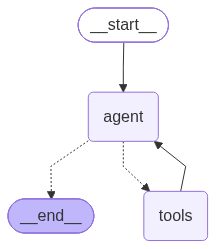

In [94]:
agent